# BANKING77: Exploratory Data Analysis

This notebook explores the BANKING77 intent classification dataset (Casanueva et al., 2020; CC-BY-4.0), 
using the shared train/validation/test split from `src/common/data.py` (seed 42, stratified 10% validation).

**Goals:** check data quality, examine class balance and sentence lengths, verify the split, 
and identify properties of the data that guide preprocessing and model design.

Figures are saved to `results/eda/`.

In [1]:
import sys, re
from pathlib import Path
from collections import Counter

# The notebook runs from notebooks/, so tell Python where the repo root is
ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.common.data import load_splits

sns.set_theme(style="whitegrid")
FIG_DIR = ROOT / "results" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

train, val, test, labels = load_splits()
print(f"train: {train.shape} | val: {val.shape} | test: {test.shape}")
train.head()

train: (9002, 3) | val: (1001, 3) | test: (3080, 3)


,text,category,label
0,"For adding money, which currencies do you accept?",supported_cards_and_currencies,54
1,What's my limit for topping up?,top_up_limits,60
2,When will my returned transaction show up on m...,Refund_not_showing_up,0
3,Which credit card top-ups do you accept?,supported_cards_and_currencies,54
4,I tried to make a transfer but it failed. will...,failed_transfer,36


**Data loaded.** The split contains 9,002 training, 1,001 validation and 3,080 test sentences. 
Each row has the raw sentence (`text`), the intent name (`category`) and its integer ID (`label`, 0–76). 
Label IDs follow alphabetical order of the intent names; because Python sorts uppercase letters first, 
`Refund_not_showing_up` receives ID 0.

In [2]:
print("Missing values:", train.isna().sum().sum(), val.isna().sum().sum(), test.isna().sum().sum())
print("Duplicate sentences in train:", train["text"].duplicated().sum())

def norm(s):
    return s.str.lower().str.strip()

print("Test sentences also in train (exact):", test["text"].isin(train["text"]).sum())
print("Test sentences also in train+val (ignoring case):",
      norm(test["text"]).isin(norm(pd.concat([train["text"], val["text"]]))).sum())

Missing values: 0 0 0
Duplicate sentences in train: 0
Test sentences also in train (exact): 0
Test sentences also in train+val (ignoring case): 6


**Data quality.** There are no missing values and no duplicate sentences in the training set, 
and no test sentence appears word-for-word in the training data. When case and surrounding spaces are ignored, 
6 test sentences (0.2% of the test set) also appear in train/validation. This is a very small potential overlap 
that is unlikely to affect results, but it is noted as a minor data-quality issue.

Examples per intent: min=35 (contactless_not_working), max=187 (card_payment_fee_charged), mean=129.9
Imbalance ratio (max/min): 5.3x


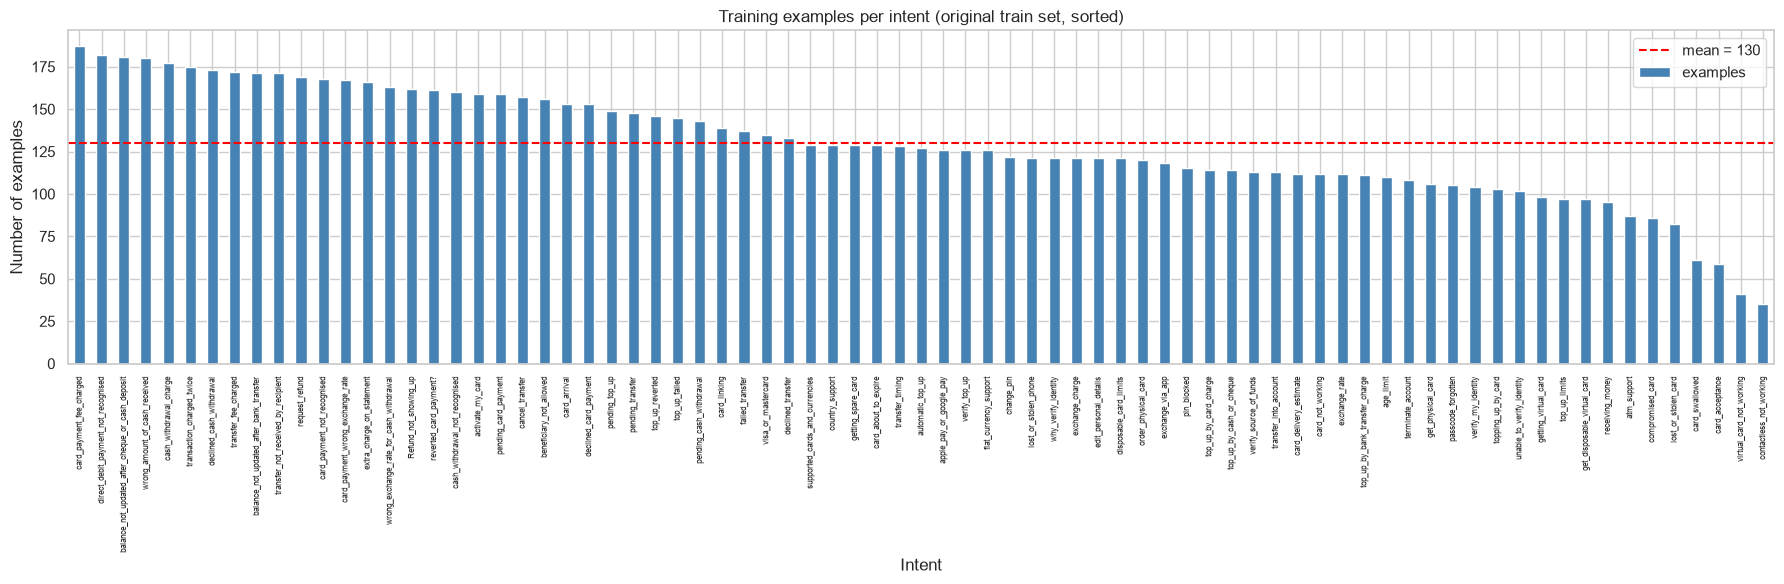

Test set, examples per intent:
min    40.0
max    40.0
Name: count, dtype: float64


In [3]:
full_train = pd.concat([train, val])  # put train + val back together = the original 10,003
counts = full_train["category"].value_counts()

print(f"Examples per intent: min={counts.min()} ({counts.idxmin()}), "
      f"max={counts.max()} ({counts.idxmax()}), mean={counts.mean():.1f}")
print(f"Imbalance ratio (max/min): {counts.max() / counts.min():.1f}x")

fig, ax = plt.subplots(figsize=(18, 6))
counts.plot(kind="bar", ax=ax, color="steelblue", label="examples")
ax.axhline(counts.mean(), color="red", linestyle="--", label=f"mean = {counts.mean():.0f}")
ax.set_title("Training examples per intent (original train set, sorted)")
ax.set_xlabel("Intent")
ax.set_ylabel("Number of examples")
ax.tick_params(axis="x", labelsize=6)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=150)
plt.show()

print("Test set, examples per intent:")
print(test["category"].value_counts().describe()[["min", "max"]])

**Class distribution.** The original training set (10,003 sentences) is imbalanced: the number of examples per intent 
ranges from 35 (`contactless_not_working`) to 187 (`card_payment_fee_charged`), a 5.3× difference, with a mean of about 130. 
Models may therefore be biased towards frequent intents, so we report macro-averaged metrics, which weight every intent equally.

The test set is perfectly balanced (40 sentences per intent). As a result, test accuracy is equal to the average recall 
across the 77 intents, which makes accuracy a fair summary measure on this test set.

Two intent names are formatted inconsistently (`Refund_not_showing_up`, `reverted_card_payment?`), a minor labelling quirk in the original data.

count    9002.000000
mean       12.043879
std         7.955406
min         2.000000
25%         7.000000
50%        10.000000
75%        13.000000
max        79.000000
Name: n_words, dtype: float64
95% of sentences have <= 30 words, 99% have <= 43


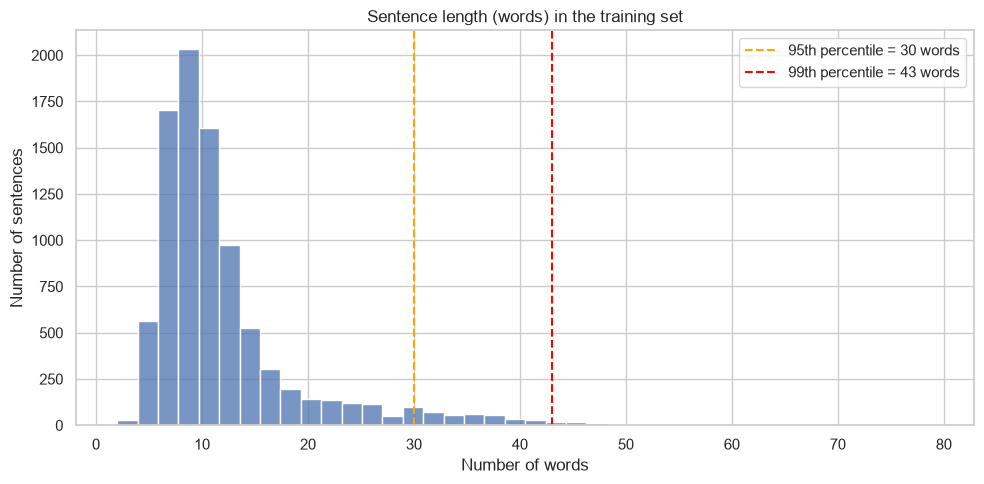

In [4]:
def tokenize(text):
    return re.findall(r"[a-z0-9']+", text.lower())

train["n_words"] = train["text"].map(lambda s: len(tokenize(s)))
print(train["n_words"].describe())

p95, p99 = np.percentile(train["n_words"], [95, 99])
print(f"95% of sentences have <= {p95:.0f} words, 99% have <= {p99:.0f}")

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(train["n_words"], bins=40, ax=ax)
ax.axvline(p95, color="orange", linestyle="--", label=f"95th percentile = {p95:.0f} words")
ax.axvline(p99, color="red", linestyle="--", label=f"99th percentile = {p99:.0f} words")
ax.set_title("Sentence length (words) in the training set")
ax.set_xlabel("Number of words")
ax.set_ylabel("Number of sentences")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "sentence_length.png", dpi=150)
plt.show()

**Sentence length.** Sentences are short and right-skewed: the median length is 10 words (mean 12, range 2–79). 
95% of sentences contain 30 words or fewer and 99% contain 43 or fewer.

For sequence models such as the BiLSTM, all sentences in a batch must have the same length, so shorter sentences 
are padded and longer ones truncated. A maximum length of 50 words keeps over 99% of sentences complete while 
avoiding unnecessary padding up to the 79-word maximum.

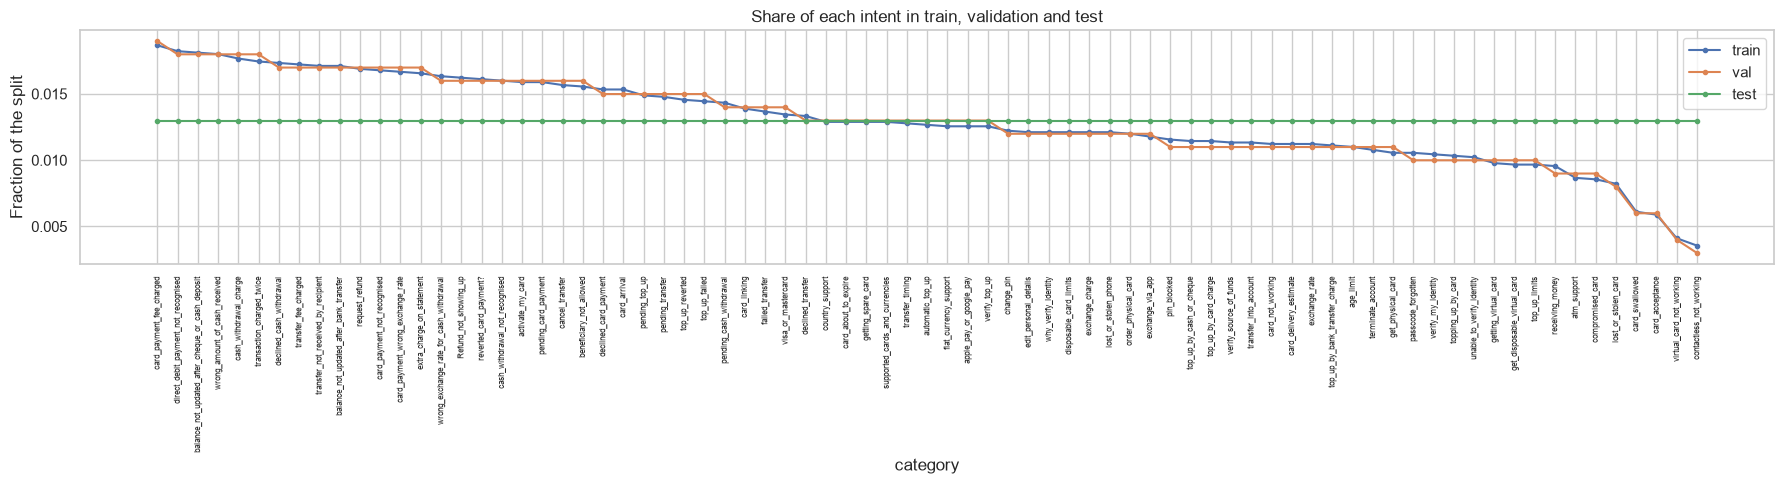

Correlation between train and val shares: 0.996


In [5]:
#are the splits consistent?
share = pd.DataFrame({
    "train": train["category"].value_counts(normalize=True),
    "val": val["category"].value_counts(normalize=True),
    "test": test["category"].value_counts(normalize=True),
}).sort_values("train", ascending=False)

fig, ax = plt.subplots(figsize=(18, 5))
share.plot(ax=ax, marker="o", markersize=3)
ax.set_title("Share of each intent in train, validation and test")
ax.set_xticks(range(len(share)))
ax.set_xticklabels(share.index, rotation=90, fontsize=6)
ax.set_ylabel("Fraction of the split")
plt.tight_layout()
plt.savefig(FIG_DIR / "split_distribution.png", dpi=150)
plt.show()

print("Correlation between train and val shares:", round(share["train"].corr(share["val"]), 3))

**Split consistency.** The share of each intent in the training and validation sets is almost identical 
(correlation 0.996), confirming that the stratified split preserved the class distribution. The validation set 
is therefore a reliable proxy for the training distribution during model selection. The test set shows a constant 
share of 1/77 for every intent because it is balanced. Intents where the test share exceeds the training share 
are under-represented in training relative to testing, so their per-class performance should be checked.

In [6]:
vocab = set(w for s in train["text"] for w in tokenize(s))
print("Unique words in train:", len(vocab))

for name, df in [("val", val), ("test", test)]:
    toks = [w for s in df["text"] for w in tokenize(s)]
    oov_rate = np.mean([w not in vocab for w in toks])
    print(f"{name}: {oov_rate:.2%} of words never appear in train")

print("\nMost common words in train:")
print(Counter(w for s in train["text"] for w in tokenize(s)).most_common(20))

Unique words in train: 2296
val: 0.80% of words never appear in train
test: 0.73% of words never appear in train

Most common words in train:
[('i', 7477), ('my', 5107), ('to', 3649), ('a', 3212), ('the', 3171), ('card', 2410), ('is', 2160), ('it', 1692), ('do', 1666), ('can', 1657), ('for', 1439), ('how', 1398), ('account', 1231), ('what', 1228), ('up', 1227), ('why', 1223), ('you', 1114), ('and', 1098), ('money', 1013), ('was', 975)]


**Vocabulary.** The training set contains only 2,296 unique words, and fewer than 1% of the words in the validation (0.80%) 
and test (0.73%) sets are unseen in training. Building the vocabulary from the training set alone (to avoid data leakage) 
therefore loses very little information.

Because the vocabulary is small and many words appear only a few times, learning word meanings from this data alone is difficult. 
This motivates using pretrained word embeddings (e.g. GloVe), which bring knowledge of word similarity learned from large text corpora.

The most frequent words include question words such as *how*, *what* and *why*. These carry intent information 
(e.g. "Why is my transfer pending?" vs "How do I transfer money?"), so stopwords are **not** removed during preprocessing.

In [7]:
for intent in ["card_arrival", "card_delivery_estimate", "card_not_working", "card_swallowed"]:
    print(f"\n{intent}:")
    for s in train.loc[train["category"] == intent, "text"].head(3):
        print("  -", s)


card_arrival:
  - I would like to track a card sent to me, how do I do that?
  - I don't have my card in 1 week.  Should I be worried?
  - My new card has not been delivered to my home yet. What is going on?

card_delivery_estimate:
  - How long does it take to receive my card?
  - How long will I have to wait for my new card?
  - Help! When will the card arrive at my home?

card_not_working:
  - The card is non-functional.
  - How do I get my card to work?
  - HOW LONG THE CARD VALIDITY

card_swallowed:
  - how to get new card after atm eats it
  - A Bank ATM did not give my card back. What do I do now?
  - The ATM did not give me my card back?


**Task difficulty.** Several intents are semantically very close. For example, `card_arrival` 
("My new card has not been delivered to my home yet") and `card_delivery_estimate` ("When will the card arrive at my home?") 
both concern waiting for a card. These pairs are likely sources of classification errors.

Some labels also appear noisy: "HOW LONG THE CARD VALIDITY" is labelled `card_not_working`, although it asks about expiry. 
Such label noise places an upper bound on achievable accuracy. The text also reflects real customer writing, 
including inconsistent capitalisation, informal phrasing ("atm eats it") and missing punctuation.

## Key findings

| Finding | Implication |
|---|---|
| Clean data; 6 near-duplicates between test and train (0.2%) | Negligible leakage risk; noted as a data-quality issue |
| 77 intents, 5.3× imbalance in training (35–187 examples) | Report macro-averaged metrics alongside accuracy |
| Test set balanced at 40 per intent | Test accuracy equals average per-class recall |
| Median sentence length 10 words; 99% ≤ 43 words | Maximum sequence length of 50 for sequence models |
| Train/validation intent shares correlate at 0.996 | Stratified split is valid; validation set is representative |
| Small vocabulary (2,296 words), < 1% OOV | Vocabulary built from training data only; pretrained embeddings are useful |
| Question words and negations carry meaning | Stopwords are kept |
| Near-identical intents and some label noise | Expect confusion between similar intents; accuracy ceiling below 100% |